## Prepare REAL-COLON Dataset

In [1]:
import os
import pandas as pd
from tqdm import tqdm
import json

lesion_info_file = r'/media/qzhao9/backup/downloads/real-colon/lesion_info.csv'
dataset_root = '/media/qzhao9/新加卷/datasets/real-colon-seg'
img_dir = 'images'
yolo_bbox_dir = 'yolo_bbox'
annot = 'annotations'

lesion_df = pd.read_csv(lesion_info_file)
lesion_info = lesion_df.set_index('unique_object_id')['histology_class'].to_dict()

sub_folders = os.listdir(dataset_root)
print(sub_folders)
df = pd.DataFrame(columns=['img', 'lesion','class'])
file_count = 0
for folder in tqdm(sub_folders, desc='Counting files', disable=False):
    yolo_bbox_full_dir = os.path.join(dataset_root, folder, yolo_bbox_dir)
    bbox_files = os.listdir(yolo_bbox_full_dir)
    file_count += len(bbox_files)

pbar = tqdm(total=file_count, desc='Analyzing dataset', disable=False)

for folder in sub_folders:
    annot_full_dir = os.path.join(dataset_root, folder, annot)
    annot_files = [f for f in os.listdir(annot_full_dir) if f.endswith('.json')]
    for annot_file in annot_files:
        annot_path = os.path.join(annot_full_dir, annot_file)
        try:
            with open(annot_path, 'r') as f:
                annot_data = json.load(f)
        except json.JSONDecodeError:
            print(f"Error decoding JSON in file: {annot_path}")
            pbar.update(1)
            continue
        img = annot_data['image']
        for entity in annot_data['entities']:
            lesion_id = entity
           
            df = pd.concat([df, pd.DataFrame([{'img': os.path.join(dataset_root, folder, img_dir, img), 
                                                'lesion': lesion_id, 
                                                'class': lesion_info.get(lesion_id, 'UNKNOWN'),
                                                'bbox': os.path.join(dataset_root, folder, yolo_bbox_dir, img.replace('.jpg', '.txt'))
                                               }])], 
                                    ignore_index=True)
        pbar.update(1)

pbar.close()
df.info()


['001-001_processed', '001-003_processed', '001-004_processed', '001-005_processed', '001-006_processed', '001-007_processed', '001-009_processed', '001-010_processed', '001-014_processed', '002-002_processed', '002-003_processed', '002-004_processed', '002-005_processed', '002-006_processed', '002-007_processed', '002-008_processed', '002-009_processed', '002-010_processed', '002-011_processed', '002-014_processed', '003-001_processed', '003-002_processed', '003-003_processed', '003-004_processed', '003-012_processed', '003-013_processed', '003-014_processed', '004-001_processed', '004-005_processed', '004-013_processed', '004-015_processed']


Analyzing dataset:  64%|██████▍   | 164974/257940 [29:31<36:41, 42.23it/s]    

Error decoding JSON in file: /media/qzhao9/新加卷/datasets/real-colon-seg/003-003_processed/annotations/003-003_95764.json


Analyzing dataset:  68%|██████▊   | 175131/257940 [32:41<30:58, 44.57it/s]  

Error decoding JSON in file: /media/qzhao9/新加卷/datasets/real-colon-seg/003-003_processed/annotations/003-003_95979.json


Analyzing dataset: 100%|██████████| 257940/257940 [1:05:35<00:00, 65.53it/s] 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267087 entries, 0 to 267086
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   img     267087 non-null  object
 1   lesion  267087 non-null  object
 2   class   267087 non-null  object
 3   bbox    267087 non-null  object
dtypes: object(4)
memory usage: 8.2+ MB


In [2]:
df.head()

,img,lesion,class,bbox
0,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...,001-001_3,AD,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...
1,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...,001-001_3,AD,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...
2,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...,001-001_3,AD,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...
3,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...,001-001_3,AD,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...
4,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...,001-001_3,AD,/media/qzhao9/新加卷/datasets/real-colon-seg/001-...


In [3]:
class_count = df.value_counts('class')
print(class_count)
df['class'].describe()

class
HP          103803
AD           85514
NO POLYP     37612
SSL          25256
TSA           9243
OTHER         5659
Name: count, dtype: int64


count     267087
unique         6
top           HP
freq      103803
Name: class, dtype: object

In [4]:
# find out number of unique images for each lesion class
unique_lesion_counts = df.groupby(by=['class'])['img'].nunique()
print(unique_lesion_counts[unique_lesion_counts > 0])

class
AD          85514
HP          95970
NO POLYP    37612
OTHER        5659
SSL         25256
TSA          9243
Name: img, dtype: int64


In [5]:
# Sampling and split dataset. test set: 20%, val set: 10%, train set: 70%
import numpy as np
np.random.seed(42)

def copy_files(src_lst, dst, partition):
    dst_part = os.path.join(dst, partition)
    os.makedirs(dst_part, exist_ok=True)
    for src in src_lst:
        if os.path.exists(src):
            os.system(f'cp "{src}" "{os.path.join(dst_part, os.path.basename(src))}"')

keys = df['class'].unique()
print(f"Total unique lesions: {len(keys)}")
target_yolo_dir = '/home/qzhao9/datasets/real-colon-seg/yolo'

img_target_dir = os.path.join(target_yolo_dir, 'images')
os.makedirs(img_target_dir, exist_ok=True)

lbl_target_dir = os.path.join(target_yolo_dir, 'labels')
os.makedirs(lbl_target_dir, exist_ok=True)

img_bbox_map = df.set_index('img')['bbox'].to_dict()

for key in tqdm(keys):
    imgs = df[df['class'] == key]['img'].unique()
    count = imgs.shape[0]
    sample_count = min(3000, count)
    train_count = int(sample_count * 0.7)
    val_count = int(sample_count * 0.1)
    test_count = sample_count - train_count - val_count
    df_lesion = pd.Series(imgs).sample(n=sample_count, random_state=42)
    
    train_set = df_lesion.iloc[:train_count]
    copy_files(train_set, img_target_dir, 'train')
    train_lbls = train_set.map(lambda tr: img_bbox_map[tr])
    copy_files(train_lbls, lbl_target_dir, 'train')
    
    val_set = df_lesion.iloc[train_count:train_count + val_count]
    copy_files(val_set, img_target_dir, 'val')
    val_lbls = val_set.map(lambda tr: img_bbox_map[tr])
    copy_files(val_lbls, lbl_target_dir, 'val')

    test_set = df_lesion.iloc[train_count + val_count:]
    copy_files(test_set, img_target_dir, 'test')
    test_lbls = test_set.map(lambda tr: img_bbox_map[tr])
    copy_files(test_lbls, lbl_target_dir, 'test')
    
    print(f"Lesion {key}: Total={count}, Sampled={sample_count}, Train={train_count}, Val={val_count}, Test={test_count}")


Total unique lesions: 6


 17%|█▋        | 1/6 [02:52<14:20, 172.13s/it]

Lesion AD: Total=85514, Sampled=3000, Train=2100, Val=300, Test=600


 33%|███▎      | 2/6 [05:20<10:32, 158.14s/it]

Lesion HP: Total=95970, Sampled=3000, Train=2100, Val=300, Test=600


...

Lesion OTHER: Total=5659, Sampled=3000, Train=2100, Val=300, Test=600


 83%|████████▎ | 5/6 [13:22<02:37, 157.07s/it]

Lesion SSL: Total=25256, Sampled=3000, Train=2100, Val=300, Test=600


100%|██████████| 6/6 [15:32<00:00, 155.45s/it]

Lesion TSA: Total=9243, Sampled=3000, Train=2100, Val=300, Test=600


In [6]:
df[df['lesion'].str.startswith('003-004')]['lesion'].value_counts()

lesion
003-004_2    3903
003-004_1    3340
003-004_3    2155
Name: count, dtype: int64

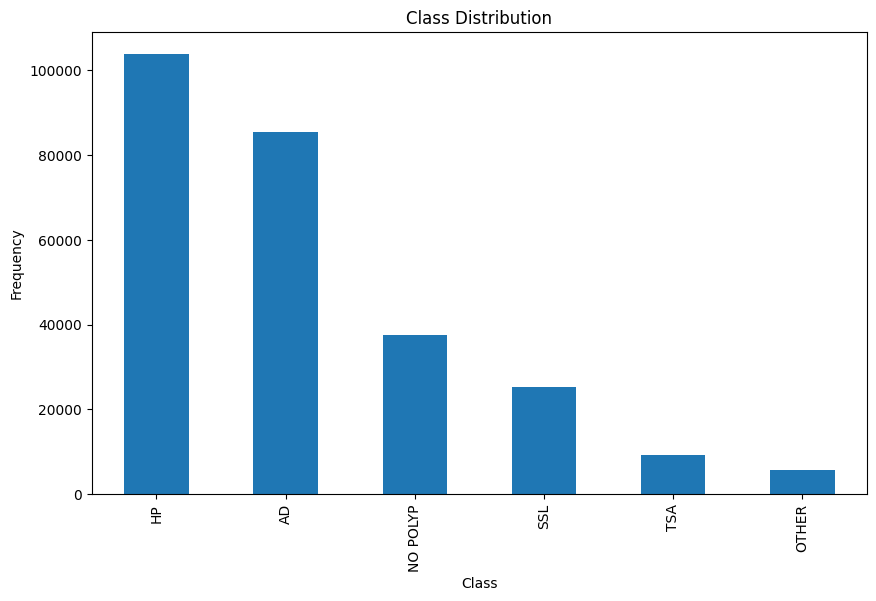

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
class_count.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

In [ ]:
class_label_map = {0: 'AD', 1: 'HP', 2: 'NO POLYP', 3: 'OTHER', 4: 'SSL', 5: 'TSA'}

,img,class,x_center,y_center,width,height


In [17]:
df.head()

,img,lesion,class
0,001-003_9574.jpg,001-003_1,AD
1,001-003_9575.jpg,001-003_1,AD
2,001-003_9576.jpg,001-003_1,AD
3,001-003_9577.jpg,001-003_1,AD
4,001-003_9578.jpg,001-003_1,AD


In [ ]:
# # Prepare Yolo dataset
# import os
# import random

# random.seed(27)

# img_dir = '/home/qzhao9/datasets/real-colon-seg/images'
# yolo_root = '/home/qzhao9/datasets/real-colon-seg/yolo'
# bbox_dir = '/home/qzhao9/datasets/real-colon-seg/yolo_bbox'
# img_train = f'{yolo_root}/images/train/'
# img_val = f'{yolo_root}/images/val/'
# lbl_train = f'{yolo_root}/labels/train/'
# lbl_val = f'{yolo_root}/labels/val/'

# images = os.listdir(img_dir)
# random.shuffle(images)
# train_split = 0.8
# train_size = int(len(images)*train_split)
# train_images = images[:train_size]
# val_images = images[train_size:]
# os.makedirs(img_train, exist_ok=True)
# os.makedirs(img_val, exist_ok=True)
# os.makedirs(lbl_train, exist_ok=True)
# os.makedirs(lbl_val, exist_ok=True)
# for ti in train_images:
#     os.system(f'cp {img_dir}/{ti} {img_train}/{ti}')
#     lbl_name = ti.replace('.jpg','.txt')
#     os.system(f'cp {bbox_dir}/{lbl_name} {lbl_train}/{lbl_name}')
# for vi in val_images:
#     os.system(f'cp {img_dir}/{vi} {img_val}/{vi}')
#     lbl_name = vi.replace('.jpg','.txt')
#     os.system(f'cp {bbox_dir}/{lbl_name} {lbl_val}/{lbl_name}')  

# Add Kvasir-SEG dataset

In [3]:
import os
import pandas as pd
import cv2
import numpy as np

data_root = '/home/qzhao9/datasets/Kvasir-SEG'

target_yolo_dir = '/home/qzhao9/datasets/real-colon-seg/yolo'

train_list_file = os.path.join(data_root, 'train.txt')

src_img_dir = os.path.join(data_root, 'images')
src_box_dir = os.path.join(data_root, 'bbox')

def copy_files(src_lst, partition):
    for line in src_lst:
        img_name = line.strip()
        img_path = os.path.join(src_img_dir, img_name + '.jpg')
        box_path = os.path.join(src_box_dir, img_name + '.csv')
        if not os.path.exists(box_path):
            print(f"Missing bbox for {img_name}")
        # Convert bbox CSV to YOLO format if needed
        bbox_pd = pd.read_csv(box_path)
        bbox_lines = []
        for index, row in bbox_pd.iterrows():
            x_center = (row['xmin'] + row['xmax']) / 2
            y_center = (row['ymin'] + row['ymax']) / 2
            size = cv2.imread(img_path).shape
            width = size[1]
            height = size[0]
            width_box = row['xmax'] - row['xmin']
            height_box = row['ymax'] - row['ymin']
            bbox_lines.append(f"3 {x_center/width} {y_center/height} {width_box/width} {height_box/height}\n") # Default class 3 (OTHER) for polyp from KVasir-SEG
        yolo_box_path = os.path.join(target_yolo_dir,f'labels/{partition}', 'kv_' + img_name + '.txt')
        with open(yolo_box_path, 'w') as f:
            f.writelines(bbox_lines)
    
        target_img_path =  os.path.join(target_yolo_dir,f'images/{partition}', 'kv_' + img_name + '.jpg')
        os.system(f'cp "{img_path}" "{target_img_path}"')


with open(train_list_file, 'r') as f:
    train_lines = f.readlines()

copy_files(train_lines, 'train')

val_list_file = os.path.join(data_root, 'val.txt')

with open(val_list_file, 'r') as f:
    val_lines = f.readlines()

# split val_lines into two halves: one for val, one for test
np.random.seed(42)
np.random.shuffle(val_lines)
mid_index = len(val_lines) // 2
val_subset = val_lines[:mid_index]
test_subset = val_lines[mid_index:]

copy_files(val_subset, 'val')

copy_files(test_subset, 'test')

# Train Yolo model

In [1]:
# Install or upgrade the ultralytics package from PyPI
%pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 2.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 6.5 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.4/802.4 kB 849.8 kB/s  0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 MB 8.6 MB/s  0:00:05m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [ultralytics] [ultralytics]n]
Note: you may need to restart the kernel to use updated packages.


In [4]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO11n model
pre_trained_model = 'yolo11n.pt' #'/home/qzhao9/code/9800/gradproj/experiments/runs/detect/train5/weights/best.pt'
model = YOLO(pre_trained_model)

# Display model information (optional)
model.info()



YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs


(181, 2624080, 0, 6.614336)

In [ ]:
import albumentations as A

custom_transforms = A.Compose(
    [A.BBoxSafeRandomCrop(erosion_rate=0.0, p=0.6),
     A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
     A.CLAHE(clip_limit=4.0, p=0.5),
     A.Rotate(limit=90, p=0.5),
     A.ZoomBlur(max_factor=[1.01,1.05], p=0.4),
     A.RandomBrightnessContrast(p=0.5),
     A.Resize(height=768, width=768, p=1.0)],
    bbox_params=A.BboxParams(format="yolo", label_fields=None),
    seed=137,
    strict=True,
)

# results = model.train(data=r"/home/qzhao9/datasets/real-colon-seg/yolo/real-colon.yaml", epochs=100, imgsz=768, batch=16, dropout=0.1)
cfg_file = r"/home/qzhao9/datasets/real-colon-seg/yolo/train_without_augmentation_cfg.yaml"
results = model.train(cfg=cfg_file, augmentations=[custom_transforms])

New https://pypi.org/project/ultralytics/8.3.252 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.250 🚀 Python-3.11.4 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3070 Laptop GPU, 7832MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, augmentations=Compose([
  BBoxSafeRandomCrop(p=0.6, erosion_rate=0.0),
  RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False),
  CLAHE(p=0.5, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8)),
  Rotate(p=0.5, border_mode=0, crop_border=False, fill=0.0, fill_mask=0.0, interpolation=1, limit=(-90.0, 90.0), mask_interpolation=0, rotate_method='largest_box'),
  ZoomBlur(p=0.4, max_factor=(1.01, 1.05), step_factor=(0.01, 0.03)),
  RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False),
  Resize(p=1.0, area_for_downscale=None, height=768, interpolation=1, mask_int

/home/qzhao9/miniconda3/envs/rag/lib/python3.11/site-packages/albumentations/core/composition.py:720: UserWarning: transforms is single transform, but a sequence is expected! Transform will be wrapped into list.
  super().__init__(


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 117.0±45.4 MB/s, size: 312.5 KB)
val: Scanning /home/qzhao9/datasets/real-colon-seg/yolo/labels/val... 1860 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1860/1860 407.2it/s 4.6s0.1s
val: New cache created: /home/qzhao9/datasets/real-colon-seg/yolo/labels/val.cache
Plotting labels to /home/qzhao9/code/9800/gradproj/experiments/runs/detect/train_without_augmentation7/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Image sizes 768 train, 768 val
Using 8 dataloader workers
Logging results to /home/qzhao9/code/9800/gradproj/experiments/runs/detect/train_without_augmentation7
Starting training for 10 epochs...
Closing dataloader mosaic
albumentations: BBoxSafeRandomCrop(p=0.6, erosion_rate=0.0),

/home/qzhao9/miniconda3/envs/rag/lib/python3.11/site-packages/albumentations/core/composition.py:720: UserWarning: transforms is single transform, but a sequence is expected! Transform will be wrapped into list.
  super().__init__(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/10      3.53G      1.593      4.081      2.065          7        768: 100% ━━━━━━━━━━━━ 843/843 4.4it/s 3:12<0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 2.4it/s 24.7s0.2s
                   all       1860       1907      0.461      0.444      0.431      0.294

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/10      3.06G      1.435      2.641      1.885         16        768: 5% ╸─────────── 39/843 6.1it/s 15.3s<2:11

In [12]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO11n model
pre_trained_model = '/home/qzhao9/code/9800/gradproj/experiments/runs/detect/train6/weights/last.pt'
model = YOLO(pre_trained_model)

In [3]:
results =model.val(cfg=cfg_file, split='test')

# You can access the metrics directly from the results object
r_dict = results.results_dict
print(f"mAP50-95: {r_dict['metrics/mAP50-95(B)']}")
print(f"Precision: {r_dict['metrics/precision(B)']}")
print(f"Recall: {r_dict['metrics/recall(B)']}")

Ultralytics 8.3.250 🚀 Python-3.11.4 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3070 Laptop GPU, 7832MiB)
YOLO11n summary (fused): 100 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 102.5±17.4 MB/s, size: 319.9 KB)
val: Scanning /home/qzhao9/datasets/real-colon-seg/yolo/labels/test.cache... 3600 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3600/3600 9.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 225/225 11.7it/s 19.2s0.2s
                   all       3600       3679      0.864      0.722      0.797      0.619
                    AD        601        601      0.744       0.54       0.63      0.453
                    HP        623        671      0.742       0.49      0.601      0.413
               NOPOLYP        607        607      0.818       0.51       0.66      0.454
                 OTHER        600        600      0.978       0.96      0.979 

In [6]:
results.results_dict

{'metrics/precision(B)': 0.9632871711026397,
 'metrics/recall(B)': 0.8860135395150857,
 'metrics/mAP50(B)': 0.9341585332615887,
 'metrics/mAP50-95(B)': 0.7438330171088765,
 'fitness': 0.7438330171088765}

In [ ]:
import matplotlib.pyplot as plt

pred_results = model([r"/home/qzhao9/datasets/kvasir-dataset/polyps/1fe26727-3cb1-4f94-85a3-acd99a380281.jpg",
                      "/home/qzhao9/datasets/kvasir-dataset/polyps/2ef9c4ad-20f5-471d-86ed-03de964305ff.jpg",
                      "/home/qzhao9/datasets/kvasir-dataset/polyps/9a48d2e8-12a5-43d6-b20f-1dc7852b4443.jpg",
                      '/home/qzhao9/datasets/Kvasir-SEG/images/cju87xn2snfmv0987sc3d9xnq.jpg',
                      '/home/qzhao9/datasets/Kvasir-SEG/images/cju7ea4om2l910801bohqjccy.jpg',
                      "/home/qzhao9/code/adpolyp.png"],
                      save=True)

pred_results[0]
# # Process results list, add all results into one image
# for result in pred_results:
#     boxes = result.boxes  # Boxes object for bounding box outputs
#     masks = result.masks  # Masks object for segmentation masks outputs
#     keypoints = result.keypoints  # Keypoints object for pose outputs
#     probs = result.probs  # Probs object for classification outputs
#     obb = result.obb  # Oriented boxes object for OBB outputs
#     result.show()  # display to screen
#     result.save(filename="result_2.jpg")  # save to disk


NameError: name 'model' is not defined